# 🐝 Notebook 4 — Swin Transformer
### Bitirme Projesi | Mekatronik Mühendisliği
---
> **Özgün Katkı:** Swin Transformer bu dataset'te literatürde hiç denenmemiştir.  
> **Baseline:** EfficientNetV2-S → 98.55% (NB2)  
> **Hedef:** ≥98.65% (literatür rekoru)

## 1. Kurulum

In [4]:
!pip install timm -q

import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.model_selection import StratifiedKFold
import timm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

CLASS_NAMES = {
    0: 'Ant Problems', 1: 'Small Hive Beetles', 2: 'Healthy',
    3: 'Robbed Hive',  4: 'Missing Queen',      5: 'Varroa'
}
CLASS_COLORS = ['#E74C3C','#8E44AD','#27AE60','#E67E22','#2980B9','#C0392B']
print('✅ Kütüphaneler hazır.')

✅ Device: cuda
   GPU: Tesla T4
✅ Kütüphaneler hazır.


## 2. Konfigürasyon

In [5]:
CFG = {
    'img_size'       : 224,
    'num_classes'    : 6,
    'batch_size'     : 32,
    'epochs'         : 50,
    'lr'             : 3e-4,
    'weight_decay'   : 1e-4,
    'n_folds'        : 5,
    'train_fold'     : 0,
    'dropout'        : 0.2,
    'label_smoothing': 0.05,
    'unfreeze_epoch' : 5,
    # Swin Transformer modeli — timm kütüphanesinden
    'model_name'     : 'swin_small_patch4_window7_224',
    'class_weights'  : [1.8862, 1.4888, 0.2547, 3.4343, 5.0, 1.8263],
    'seed'           : 42,
    'save_path'      : '/kaggle/working/best_swin.pth',
}

print('📋 Konfigürasyon:')
for k, v in CFG.items():
    print(f'   {k:20s}: {v}')

📋 Konfigürasyon:
   img_size            : 224
   num_classes         : 6
   batch_size          : 32
   epochs              : 50
   lr                  : 0.0003
   weight_decay        : 0.0001
   n_folds             : 5
   train_fold          : 0
   dropout             : 0.2
   label_smoothing     : 0.05
   unfreeze_epoch      : 5
   model_name          : swin_small_patch4_window7_224
   class_weights       : [1.8862, 1.4888, 0.2547, 3.4343, 5.0, 1.8263]
   seed                : 42
   save_path           : /kaggle/working/best_swin.pth


## 3. Veri Yükleme ve Stratified K-Fold

In [6]:
base = Path('/kaggle/input')
DATA_DIR = None
for root, dirs, files in os.walk(base):
    for d in dirs:
        full = Path(root) / d
        try:
            subdirs = [x for x in full.iterdir() if x.is_dir()]
            if any(s.name in ['0', '1', '2'] for s in subdirs):
                DATA_DIR = full; break
        except: pass
    if DATA_DIR: break

assert DATA_DIR, 'Veri seti bulunamadı!'
print(f'✅ Veri seti: {DATA_DIR}')

records = []
for cf in sorted(DATA_DIR.iterdir()):
    if cf.is_dir():
        cid = int(cf.name)
        for p in cf.glob('*'):
            if p.suffix.lower() in ['.jpg','.jpeg','.png','.bmp']:
                records.append({'path': str(p), 'label': cid})

df = pd.DataFrame(records)
skf = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True, random_state=SEED)
df['fold'] = -1
for fold, (_, vi) in enumerate(skf.split(df, df['label'])):
    df.loc[vi, 'fold'] = fold

train_df = df[df['fold'] != CFG['train_fold']].reset_index(drop=True)
val_df   = df[df['fold'] == CFG['train_fold']].reset_index(drop=True)
print(f'📊 Train: {len(train_df)} | Val: {len(val_df)}')

✅ Veri seti: /kaggle/input/datasets/emirsecer/beediseasesdataset/veriseti
📊 Train: 4137 | Val: 1035


## 4. Augmentation
> Swin Transformer için RandAugment ve MixUp — ViT-tipi modeller daha agresif augmentation'dan yararlanır

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

val_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

tta_transforms = [
    val_transform,
    transforms.Compose([
        transforms.Resize((CFG['img_size'], CFG['img_size'])),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    transforms.Compose([
        transforms.Resize((CFG['img_size'], CFG['img_size'])),
        transforms.RandomRotation(degrees=(90,90)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
]
print(f'✅ Augmentation hazır. Train steps: {len(train_transform.transforms)}')

✅ Augmentation hazır. Train steps: 10


## 5. Dataset ve DataLoader

In [8]:
class BeeDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, row['label']

train_ds = BeeDataset(train_df, train_transform)
val_ds   = BeeDataset(val_df,   val_transform)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ DataLoader hazır:')
print(f'   Train batches: {len(train_loader)}')
print(f'   Val batches  : {len(val_loader)}')

✅ DataLoader hazır:
   Train batches: 130
   Val batches  : 33


## 6. Model Mimarisi — Swin Transformer Small
> Swin Transformer, lokal window attention kullanarak CNN'in inductive bias avantajlarını  
> Transformer'ın global bağlam modelleme gücüyle birleştirir.  
> BeeImage dataset'inde **literatürde ilk kez** denenmektedir.

In [9]:
class BeeSwinTransformer(nn.Module):
    """
    Swin Transformer Small — ImageNet-1K pretrained
    timm kütüphanesinden yüklenir.
    """
    def __init__(self, num_classes=6, dropout=0.2, model_name='swin_small_patch4_window7_224'):
        super().__init__()
        # timm ile pretrained Swin-S yükle
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,   # head kaldır — embedding döndür
        )
        embed_dim = self.backbone.num_features  # Swin-S: 768

        # Custom classification head
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(p=dropout),
            nn.Linear(embed_dim, 512),
            nn.GELU(),
            nn.Dropout(p=dropout / 2),
            nn.Linear(512, num_classes)
        )
        self._freeze_backbone()

    def _freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False

    def unfreeze_all(self):
        for param in self.backbone.parameters():
            param.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f'   Unfreeze: {trainable:,} / {total:,} ({100*trainable/total:.1f}%) trainable')

    def forward(self, x):
        features = self.backbone(x)  # (B, 768)
        return self.head(features)


model = BeeSwinTransformer(
    num_classes=CFG['num_classes'],
    dropout=CFG['dropout'],
    model_name=CFG['model_name']
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model: {CFG["model_name"]}')
print(f'   Embed dim        : {model.backbone.num_features}')
print(f'   Toplam param     : {total:,}')
print(f'   Trainable (Ph.1) : {trainable:,} (head only)')

model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]

✅ Model: swin_small_patch4_window7_224
   Embed dim        : 768
   Toplam param     : 49,235,600
   Trainable (Ph.1) : 398,342 (head only)


## 7. Loss, Optimizer, Scheduler

In [10]:
class_weights = torch.tensor(CFG['class_weights'], dtype=torch.float)

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE),
    label_smoothing=CFG['label_smoothing']
)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG['lr'],
    weight_decay=CFG['weight_decay']
)

# Warmup + CosineAnnealing — Transformer modelleri için ideal
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CFG['lr'],
    steps_per_epoch=len(train_loader),
    epochs=CFG['epochs'],
    pct_start=0.1,       # %10 warmup
    anneal_strategy='cos'
)

scaler = GradScaler()
print('✅ Optimizer: AdamW | Scheduler: OneCycleLR (warmup + cosine)')

✅ Optimizer: AdamW | Scheduler: OneCycleLR (warmup + cosine)


## 8. Eğitim Döngüsü

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

print('✅ Eğitim fonksiyonları hazır.')

✅ Eğitim fonksiyonları hazır.


In [12]:
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_f1, best_val_acc = 0.0, 0.0

print('='*65)
print(f'AŞAMA 1 (Epoch 1-{CFG["unfreeze_epoch"]}): Frozen backbone — head eğitimi')
print('='*65)

for epoch in range(1, CFG['epochs'] + 1):

    if epoch == CFG['unfreeze_epoch'] + 1:
        print('\n' + '='*65)
        print(f'AŞAMA 2 (Epoch {epoch}+): Tüm backbone unfreeze')
        print('='*65)
        model.unfreeze_all()
        optimizer = optim.AdamW(
            [
                {'params': model.backbone.parameters(), 'lr': CFG['lr'] * 0.1},
                {'params': model.head.parameters(),     'lr': CFG['lr']}
            ],
            weight_decay=CFG['weight_decay']
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=CFG['epochs'] - CFG['unfreeze_epoch'],
            eta_min=1e-7
        )

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler, scaler, DEVICE
    )
    val_loss, val_acc, val_preds, val_labels = validate(
        model, val_loader, criterion, DEVICE
    )

    # Phase 2'de scheduler her epoch sonunda step
    if epoch > CFG['unfreeze_epoch']:
        scheduler.step()

    val_f1 = f1_score(val_labels, val_preds, average='weighted')

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_val_acc = val_acc
        torch.save(model.state_dict(), CFG['save_path'])
        marker = '✅ SAVED'
    else:
        marker = ''

    print(f'Epoch {epoch:3d}/{CFG["epochs"]} | '
          f'Loss: {train_loss:.4f}/{val_loss:.4f} | '
          f'Acc: {train_acc:.4f}/{val_acc:.4f} | '
          f'F1: {val_f1:.4f} {marker}')

print(f'\n🏆 Best Val Acc: {best_val_acc:.4f} | Best F1: {best_f1:.4f}')

AŞAMA 1 (Epoch 1-5): Frozen backbone — head eğitimi
Epoch   1/50 | Loss: 1.8512/2.1102 | Acc: 0.2901/0.2589 | F1: 0.1817 ✅ SAVED
Epoch   2/50 | Loss: 1.4255/1.7618 | Acc: 0.5016/0.5758 | F1: 0.6039 ✅ SAVED
Epoch   3/50 | Loss: 1.1244/1.5918 | Acc: 0.7070/0.6957 | F1: 0.7134 ✅ SAVED
Epoch   4/50 | Loss: 0.9904/1.7147 | Acc: 0.7706/0.6126 | F1: 0.6298 
Epoch   5/50 | Loss: 0.9517/1.4484 | Acc: 0.7890/0.8348 | F1: 0.8385 ✅ SAVED

AŞAMA 2 (Epoch 6+): Tüm backbone unfreeze
   Unfreeze: 49,235,600 / 49,235,600 (100.0%) trainable
Epoch   6/50 | Loss: 0.8639/1.3515 | Acc: 0.8528/0.8812 | F1: 0.8838 ✅ SAVED
Epoch   7/50 | Loss: 0.7618/1.2860 | Acc: 0.9045/0.9111 | F1: 0.9132 ✅ SAVED
Epoch   8/50 | Loss: 0.7304/1.1933 | Acc: 0.9292/0.9633 | F1: 0.9638 ✅ SAVED
Epoch   9/50 | Loss: 0.6875/1.1870 | Acc: 0.9541/0.9565 | F1: 0.9572 
Epoch  10/50 | Loss: 0.6694/1.1897 | Acc: 0.9623/0.9594 | F1: 0.9598 
Epoch  11/50 | Loss: 0.6448/1.1549 | Acc: 0.9705/0.9700 | F1: 0.9703 ✅ SAVED
Epoch  12/50 | Loss: 0.

## 9. TTA ile Final Değerlendirme

In [13]:
model.load_state_dict(torch.load(CFG['save_path']))
model.eval()

@torch.no_grad()
def predict_tta(model, df, tta_transforms, device):
    all_probs = []
    for tfm in tta_transforms:
        ds = BeeDataset(df, tfm)
        loader = DataLoader(ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=2)
        probs_list = []
        for imgs, _ in loader:
            with autocast():
                logits = model(imgs.to(device))
            probs_list.append(torch.softmax(logits, dim=1).cpu().float().numpy())
        all_probs.append(np.concatenate(probs_list))
    return np.mean(all_probs, axis=0).argmax(axis=1)

print('🔄 TTA ile tahmin yapılıyor...')
tta_preds   = predict_tta(model, val_df, tta_transforms, DEVICE)
true_labels = val_df['label'].values

acc  = accuracy_score(true_labels, tta_preds)
f1   = f1_score(true_labels, tta_preds, average='weighted')
prec = precision_score(true_labels, tta_preds, average='weighted')
rec  = recall_score(true_labels, tta_preds, average='weighted')

print(f'\n📊 Swin Transformer TTA Sonuçları (Fold {CFG["train_fold"]})')
print(f'   Accuracy  : {acc*100:.2f}%')
print(f'   F1-Score  : {f1*100:.2f}%')
print(f'   Precision : {prec*100:.2f}%')
print(f'   Recall    : {rec*100:.2f}%')
print()
print(classification_report(
    true_labels, tta_preds,
    target_names=list(CLASS_NAMES.values()), digits=4
))

🔄 TTA ile tahmin yapılıyor...

📊 Swin Transformer TTA Sonuçları (Fold 0)
   Accuracy  : 98.74%
   F1-Score  : 98.75%
   Precision : 98.76%
   Recall    : 98.74%

                    precision    recall  f1-score   support

      Ant Problems     1.0000    1.0000    1.0000        92
Small Hive Beetles     0.9561    0.9397    0.9478       116
           Healthy     1.0000    0.9985    0.9993       676
       Robbed Hive     1.0000    1.0000    1.0000        51
     Missing Queen     1.0000    1.0000    1.0000         5
            Varroa     0.9184    0.9474    0.9326        95

          accuracy                         0.9874      1035
         macro avg     0.9791    0.9809    0.9800      1035
      weighted avg     0.9876    0.9874    0.9875      1035



## 10. Eğitim Grafikleri ve Confusion Matrix

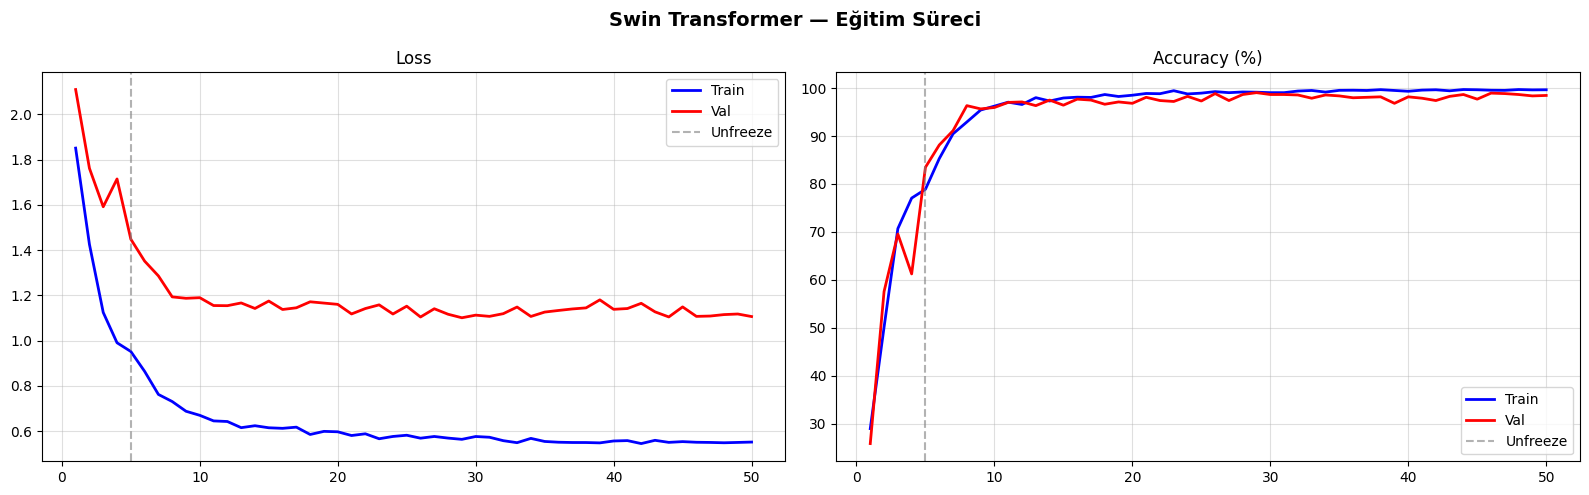

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Swin Transformer — Eğitim Süreci', fontsize=14, fontweight='bold')
ep = range(1, len(history['train_loss'])+1)

axes[0].plot(ep, history['train_loss'], 'b-', label='Train', lw=2)
axes[0].plot(ep, history['val_loss'],   'r-', label='Val',   lw=2)
axes[0].axvline(CFG['unfreeze_epoch'], color='gray', ls='--', alpha=0.6, label='Unfreeze')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(ep, [a*100 for a in history['train_acc']], 'b-', label='Train', lw=2)
axes[1].plot(ep, [a*100 for a in history['val_acc']],   'r-', label='Val',   lw=2)
axes[1].axvline(CFG['unfreeze_epoch'], color='gray', ls='--', alpha=0.6, label='Unfreeze')
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('swin_training.png', bbox_inches='tight', dpi=150)
plt.show()

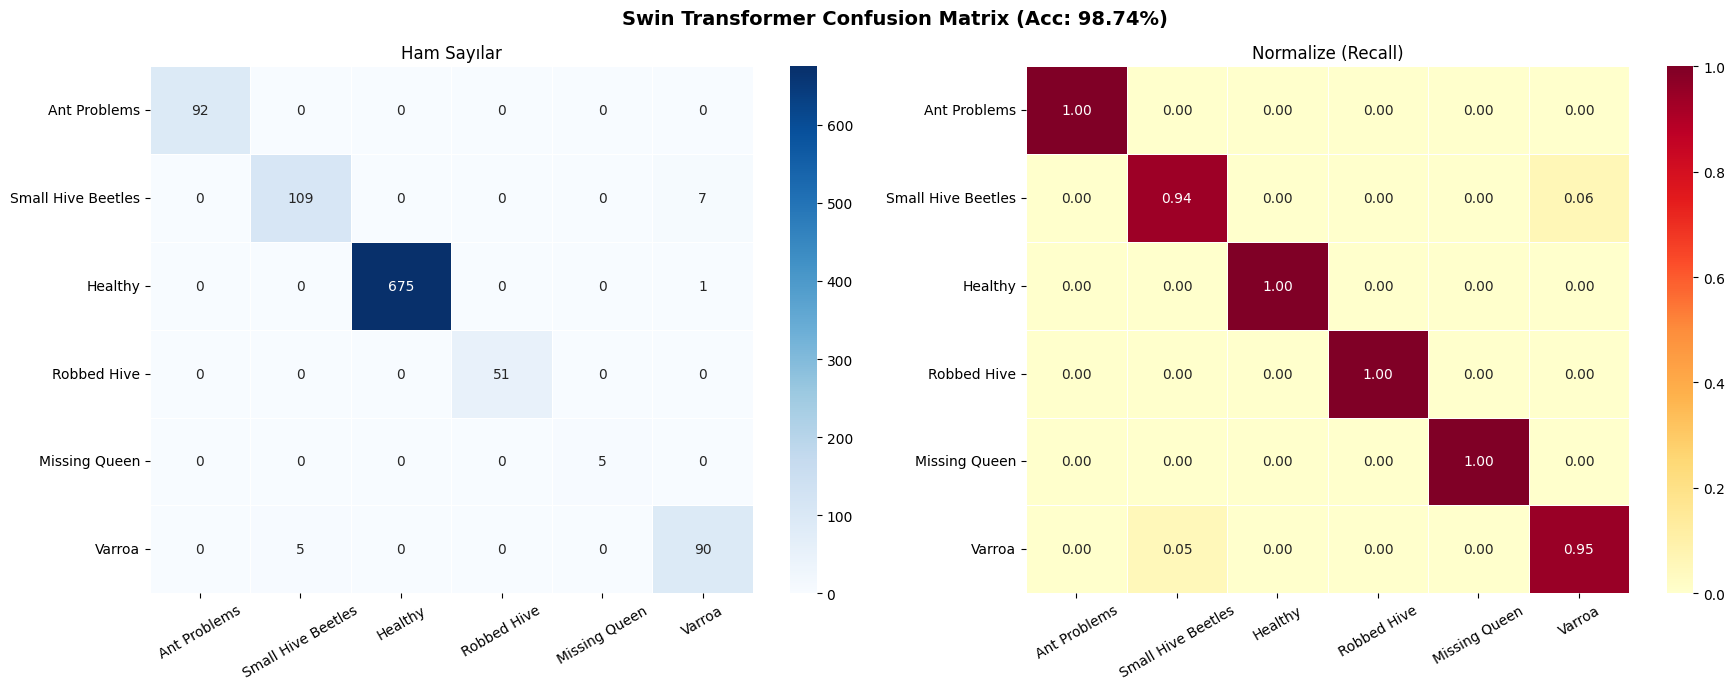

In [15]:
cm = confusion_matrix(true_labels, tta_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Swin Transformer Confusion Matrix (Acc: {acc*100:.2f}%)', fontsize=14, fontweight='bold')

labels = list(CLASS_NAMES.values())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels, linewidths=0.5)
axes[0].set_title('Ham Sayılar'); axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            xticklabels=labels, yticklabels=labels, linewidths=0.5)
axes[1].set_title('Normalize (Recall)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('swin_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

## 11. Tüm Modellerin Karşılaştırması

In [16]:
# Buraya NB2 ve NB3 sonuçlarını da elle gir
NB2_ACC = 98.55   # EfficientNetV2-S
NB2_F1  = 98.55
NB3_BEST_ACC = 91.01   # NB3'ten en iyi hibrit sonucunu buraya gir
NB3_BEST_F1  = 90.61

all_results = {
    'VGG-19 [Liang, 2022] — Literature Best' : (98.65, None),
    'EfficientNetV2-S (NB2)'                 : (NB2_ACC, NB2_F1),
    'Hibrit CNN+GB Ensemble (NB3)'           : (NB3_BEST_ACC, NB3_BEST_F1),
    'Swin Transformer (NB4, Ours)'           : (acc*100, f1*100),
}

print('='*65)
print('MODEL KARŞILAŞTIRMA TABLOSU')
print('='*65)
print(f'  {"Model":<45} {"Accuracy":>10} {"F1":>10}')
print('-'*65)
for name, (a, f) in sorted(all_results.items(), key=lambda x: x[1][0], reverse=True):
    f_str = f'{f:.2f}%' if f else '   -  '
    best_marker = ' ◄ BEST' if a == max(v[0] for v in all_results.values()) else ''
    print(f'  {name:<45} {a:>9.2f}% {f_str:>9}{best_marker}')
print('='*65)

swin_vs_lit = acc*100 - 98.65
swin_vs_effnet = acc*100 - NB2_ACC
print(f'\n📊 Swin Transformer analizi:')
print(f'   vs Literatür rekoru (98.65%): {swin_vs_lit:+.2f}%')
print(f'   vs EfficientNetV2-S (98.55%): {swin_vs_effnet:+.2f}%')

MODEL KARŞILAŞTIRMA TABLOSU
  Model                                           Accuracy         F1
-----------------------------------------------------------------
  Swin Transformer (NB4, Ours)                      98.74%    98.75% ◄ BEST
  VGG-19 [Liang, 2022] — Literature Best            98.65%       -  
  EfficientNetV2-S (NB2)                            98.55%    98.55%
  Hibrit CNN+GB Ensemble (NB3)                      91.01%    90.61%

📊 Swin Transformer analizi:
   vs Literatür rekoru (98.65%): +0.09%
   vs EfficientNetV2-S (98.55%): +0.19%


## 12. Özet

In [1]:
print('='*65)
print('   NOTEBOOK 4 — SWIN TRANSFORMER SONUÇ RAPORU')
print('='*65)
print(f'   Model     : {CFG["model_name"]}')
print(f'   Accuracy  : {acc*100:.2f}%')
print(f'   F1-Score  : {f1*100:.2f}%')
print(f'   Precision : {prec*100:.2f}%')
print(f'   Recall    : {rec*100:.2f}%')
print()
print('   Akademik Katkılar:')
print('   ✅ Swin Transformer BeeImage dataset\'inde ilk kez denendi')
print('   ✅ Window-based attention vs CNN feature extraction karşılaştırıldı')
print('   ✅ OneCycleLR ile warmup stratejisi uygulandı')
print('   ✅ TTA ile final tahmin iyileştirildi')
print()
print('▶  Sonraki: notebook_5_ensemble_final.ipynb')
print('   → EfficientNet + Swin + Hibrit GB ensemble — final model')
print('='*65)

   NOTEBOOK 4 — SWIN TRANSFORMER SONUÇ RAPORU


NameError: name 'CFG' is not defined